In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import requests
from PIL import Image
from io import BytesIO

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
EPOCHS = 5
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
MODEL_SAVE_PATH = "vl2lite_final.pth"

print(f"Running on {DEVICE}")

# ==========================================
# 1. MODEL DEFINITIONS & HELPER CLASSES
# ==========================================

class Connector(nn.Module):
    def __init__(self, input_dim=2048, output_dim=512):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, output_dim)
        )
    def forward(self, x): return self.layer(x)

def get_teacher_model():
    """Loads and freezes the CLIP Teacher model."""
    print("Loading Teacher (CLIP)...")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model

def get_student_model(num_classes=10):
    """Loads the ResNet50 Student model."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

# ==========================================
# 2. ROBUST FEATURE EXTRACTION (THE FIX)
# ==========================================

def get_clip_image_features(teacher_model, images):
    """Safely extracts image features regardless of HuggingFace version."""
    with torch.no_grad():
        if hasattr(teacher_model, "get_image_features"):
            features = teacher_model.get_image_features(images)
        else:
            vision_outputs = teacher_model.vision_model(images)
            if hasattr(vision_outputs, 'pooler_output') and vision_outputs.pooler_output is not None:
                pooled_output = vision_outputs.pooler_output
            else:
                pooled_output = vision_outputs[1]
            features = teacher_model.visual_projection(pooled_output)

        # FINAL SAFETY CHECK: Extract pure tensor from HuggingFace objects
        if not isinstance(features, torch.Tensor):
            if hasattr(features, 'pooler_output'):
                features = features.pooler_output
            elif hasattr(features, "image_embeds"):
                features = features.image_embeds
            elif hasattr(features, "logits"):
                features = features.logits
            elif isinstance(features, tuple):
                features = features[0]

        if not isinstance(features, torch.Tensor):
            raise TypeError(f"Failed to extract tensor features from image. Object type: {type(features)}")

        return features / features.norm(p=2, dim=-1, keepdim=True)

def get_text_anchors(class_names):
    """Safely extracts text anchors regardless of HuggingFace version."""
    print("Generating Text Anchors...")
    teacher = get_teacher_model()
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    prompts = [f"a photo of a {c}" for c in class_names]
    inputs = processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        if hasattr(teacher, "get_text_features"):
            txt_feats = teacher.get_text_features(**inputs)
        else:
            txt_out = teacher.text_model(**inputs)
            if hasattr(txt_out, 'pooler_output') and txt_out.pooler_output is not None:
                pooled_output = txt_out.pooler_output
            else:
                pooled_output = txt_out[1]
            txt_feats = teacher.text_projection(pooled_output)

        # FINAL SAFETY CHECK: Extract pure tensor
        if not isinstance(txt_feats, torch.Tensor):
            if hasattr(txt_feats, 'pooler_output'):
                txt_feats = txt_feats.pooler_output
            elif hasattr(txt_feats, "text_embeds"):
                txt_feats = txt_feats.text_embeds
            elif hasattr(txt_feats, "logits"):
                txt_feats = txt_feats.logits
            elif isinstance(txt_feats, tuple):
                txt_feats = txt_feats[0]

        if not isinstance(txt_feats, torch.Tensor):
            raise TypeError(f"Failed to extract tensor features from text. Object type: {type(txt_feats)}")

        txt_feats = txt_feats / txt_feats.norm(p=2, dim=-1, keepdim=True)

    del teacher  # Free GPU memory
    torch.cuda.empty_cache()
    return txt_feats

# ==========================================
# 3. PRE-COMPUTATION & KD LOSS FUNCTION
# ==========================================
# ==========================================
# 3. PRE-COMPUTATION & KD LOSS FUNCTION (MEMORY FIXED)
# ==========================================

class DistillationDataset(torch.utils.data.Dataset):
    """
    Custom Dataset that combines lazy-loaded images with pre-computed teacher features in RAM.
    This prevents the 30GB System RAM crash!
    """
    def __init__(self, original_dataset, teacher_features):
        self.original_dataset = original_dataset
        self.teacher_features = teacher_features

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        teacher_feat = self.teacher_features[idx]
        return img, teacher_feat, label

def precompute_teacher_features():
    print("\n--- Phase 1: Pre-computing Teacher Features ---")
    teacher = get_teacher_model()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Crucial: shuffle=False to keep features aligned with images
    raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    loader = DataLoader(raw_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    all_feats = []

    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(loader):
            imgs = imgs.to(DEVICE)

            # Extract features
            feats = get_clip_image_features(teacher, imgs)

            # We ONLY store the tiny 512-d feature vectors, NOT the images!
            all_feats.append(feats.cpu())

            if i % 100 == 0:
                print(f"  Processed {i}/{len(loader)}")

    teacher_features_tensor = torch.cat(all_feats)
    print(f"Pre-computation Done. Cached features shape: {teacher_features_tensor.shape}")

    del teacher  # Free GPU memory
    torch.cuda.empty_cache()

    # Return our custom memory-safe dataset
    return DistillationDataset(raw_dataset, teacher_features_tensor)

def calculate_knowledge_distillation_loss(student_logits, student_projected, teacher_features, text_anchors, labels, epoch_progress):
    # Dynamic Weights
    w_task = 0.5 + (0.5 * epoch_progress)
    w_distill = 1.0 - (0.9 * epoch_progress)

    # Losses
    loss_task = F.cross_entropy(student_logits, labels)
    loss_visual = F.mse_loss(student_projected, teacher_features)
    loss_text = F.mse_loss(student_projected, text_anchors[labels])

    return (w_task * loss_task) + (w_distill * (loss_visual + loss_text))




Running on cuda


In [6]:

# ==========================================
# 4. TRAINING WITH VALIDATION
# ==========================================

def train_and_validate():
    train_dataset = precompute_teacher_features()
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    text_anchors = get_text_anchors(CLASSES)

    student = get_student_model(len(CLASSES))
    connector = Connector().to(DEVICE)
    optimizer = optim.Adam(list(student.parameters()) + list(connector.parameters()), lr=1e-4)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("\n--- Phase 2: Training Student ---")
    for epoch in range(EPOCHS):
        student.train()
        connector.train()
        t_loss, t_correct, t_total = 0, 0, 0
        progress = epoch / EPOCHS

        for imgs, t_feats, lbls in train_loader:
            imgs, lbls, t_feats = imgs.to(DEVICE), lbls.to(DEVICE), t_feats.to(DEVICE)
            optimizer.zero_grad()

            # Forward Hook Simulation
            x = student.conv1(imgs)
            x = student.bn1(x)
            x = student.relu(x)
            x = student.maxpool(x)
            x = student.layer1(x)
            x = student.layer2(x)
            x = student.layer3(x)
            x = student.layer4(x)
            x = student.avgpool(x)
            feat_raw = torch.flatten(x, 1)

            logits = student.fc(feat_raw)
            feat_proj = connector(feat_raw)
            feat_proj = feat_proj / feat_proj.norm(p=2, dim=-1, keepdim=True)

            # --- SEPARATED KD LOSS ---
            loss = calculate_knowledge_distillation_loss(logits, feat_proj, t_feats, text_anchors, lbls, progress)
            loss.backward()
            optimizer.step()

            t_loss += loss.item()
            _, pred = torch.max(logits, 1)
            t_correct += (pred == lbls).sum().item()
            t_total += lbls.size(0)

        student.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = student(imgs)
                l = F.cross_entropy(out, lbls)
                v_loss += l.item()
                _, pred = torch.max(out, 1)
                v_correct += (pred == lbls).sum().item()
                v_total += lbls.size(0)

        train_acc = 100 * t_correct / t_total
        val_acc = 100 * v_correct / v_total
        avg_t_loss = t_loss / len(train_loader)
        avg_v_loss = v_loss / len(test_loader)

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | Train Loss {avg_t_loss:.4f}")

    torch.save(student.state_dict(), MODEL_SAVE_PATH)
    return history, student, test_loader

# ==========================================
# 5. VISUALIZATION & METRICS
# ==========================================

def plot_results(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Validation Acc')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.show()

def plot_confusion_matrix_func(model, loader):
    print("\n--- Generating Confusion Matrix ---")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(DEVICE))
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix on Test Data')
    plt.show()


In [7]:

# ==========================================
# 6. TESTING SUITE (20 Images)
# ==========================================

def test_on_20_images(model):
    print("\n--- Testing on 20 Random Web Images ---")
    urls = [
        "https://upload.wikimedia.org/wikipedia/commons/5/53/Weimaraner_dog.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a5/Cunard_Line%27s_Queen_Elizabeth_2.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/e/e3/2016_Lamborghini_Centenario_LP_770-4.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/0/0c/Green_Tree_Frog_-_Litoria_caerulea.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/d/d9/Asian_Elephant_Kristiansand_Zoo.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/c/c5/Boeing_747-400_ER_Air_France_F-GISE_CDG_2003-8-23.png",
        "https://upload.wikimedia.org/wikipedia/commons/d/dd/Mule_deer_grazing.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/6/6d/Fire_truck_01.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/d/d4/Siberian_Tiger_by_Malene_Th.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/9/9e/Oryx_gazella_1540326.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/1/1a/Volkswagen_Golf_IV_front_20080326.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/8/8b/American_Bison_k5680-1.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_March_2010-1.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/f/fb/Car_17.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/ae/Kymco_Super_8_50.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/8/82/Sperm_whale_fluke.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/b/b3/Fighter_jet_f-16.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a9/Truck_loading.jpg"
    ]

    transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    model.eval()
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i, url in enumerate(urls):
        try:
            resp = requests.get(url, timeout=5)
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            tensor = transform(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(tensor)
                probs = F.softmax(out, dim=1)
                conf, pred_idx = torch.max(probs, 1)

            label = CLASSES[pred_idx.item()]
            axes[i].imshow(img)
            axes[i].set_title(f"{label}\n{conf.item()*100:.1f}%")
            axes[i].axis('off')
        except:
            axes[i].set_title("Load Error")
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# 7. COMPARISON (Student vs ResNet50)
# ==========================================

def compare_models_25_images(student_model):
    print("\n--- COMPARISON: Distilled Student vs Standard ResNet50 ---")

    baseline = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    baseline.fc = nn.Linear(baseline.fc.in_features, 10)
    baseline.to(DEVICE); baseline.eval(); student_model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=25, shuffle=True)
    images, labels = next(iter(loader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    with torch.no_grad():
        s_out = student_model(images)
        _, s_preds = torch.max(s_out, 1)
        b_out = baseline(images)
        _, b_preds = torch.max(b_out, 1)

    fig, axes = plt.subplots(5, 5, figsize=(15, 16))
    axes = axes.flatten()
    s_score, b_score = 0, 0
    images_cpu = images.cpu()

    for i in range(25):
        img = np.clip(images_cpu[i].permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        s_correct = (s_preds[i] == labels[i])
        b_correct = (b_preds[i] == labels[i])
        if s_correct: s_score += 1
        if b_correct: b_score += 1

        col_s = "green" if s_correct else "red"
        col_b = "green" if b_correct else "red"
        axes[i].imshow(img)
        axes[i].set_title(f"True: {CLASSES[labels[i]]}\nDistilled: {CLASSES[s_preds[i]]}", color=col_s, fontsize=9)
        axes[i].set_xlabel(f"Standard: {CLASSES[b_preds[i]]}", color=col_b, fontsize=9)
        axes[i].set_xticks([]); axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()

    print(f"\nFINAL SCORE on 25 Images:")
    print(f"Distilled Model: {s_score}/25 ({(s_score/25)*100:.1f}%)")
    print(f"Standard Model : {b_score}/25 ({(b_score/25)*100:.1f}%)")
    print(f"Improvement: +{((s_score - b_score)/25)*100:.1f}%")


--- Phase 1: Pre-computing Teacher Features ---
Loading Teacher (CLIP)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Processed 0/782
  Processed 100/782
  Processed 200/782
  Processed 300/782
  Processed 400/782
  Processed 500/782
  Processed 600/782
  Processed 700/782
Pre-computation Done. Cached features shape: torch.Size([50000, 512])
Generating Text Anchors...
Loading Teacher (CLIP)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]



--- Phase 2: Training Student ---
Epoch 1: Train Acc 90.65% | Val Acc 94.51% | Train Loss 0.1460
Epoch 2: Train Acc 95.66% | Val Acc 94.56% | Train Loss 0.0790
Epoch 3: Train Acc 97.27% | Val Acc 94.16% | Train Loss 0.0585
Epoch 4: Train Acc 97.69% | Val Acc 94.59% | Train Loss 0.0550
Epoch 5: Train Acc 98.09% | Val Acc 94.36% | Train Loss 0.0514


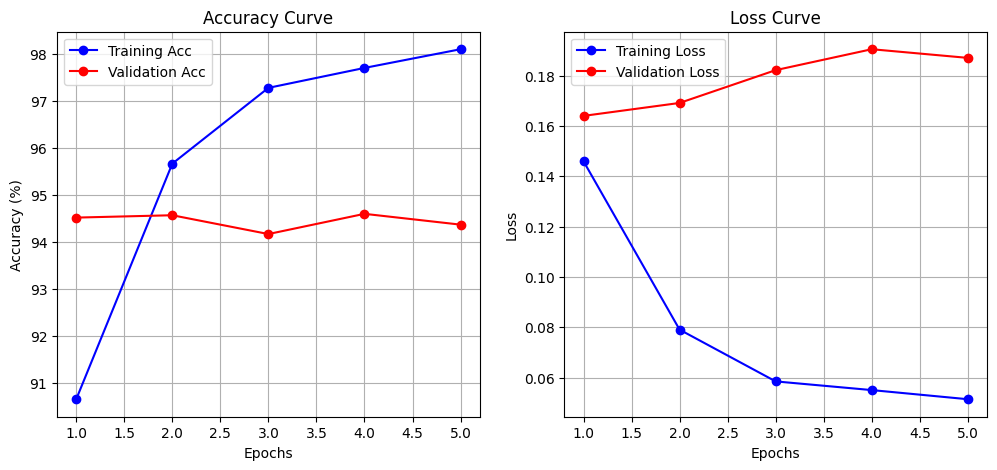


--- Generating Confusion Matrix ---


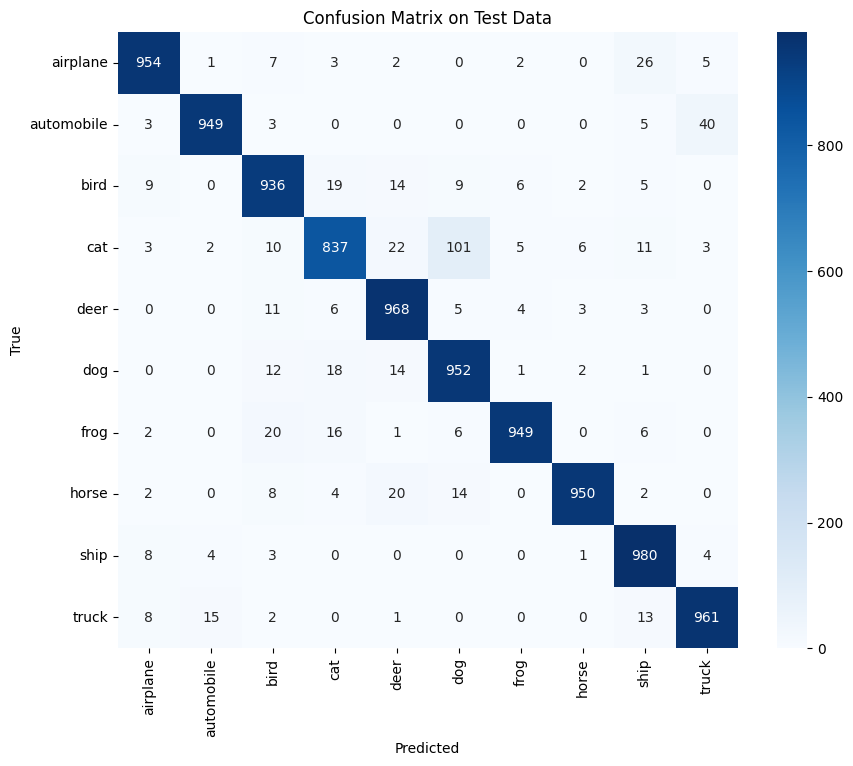


--- Testing on 20 Random Web Images ---


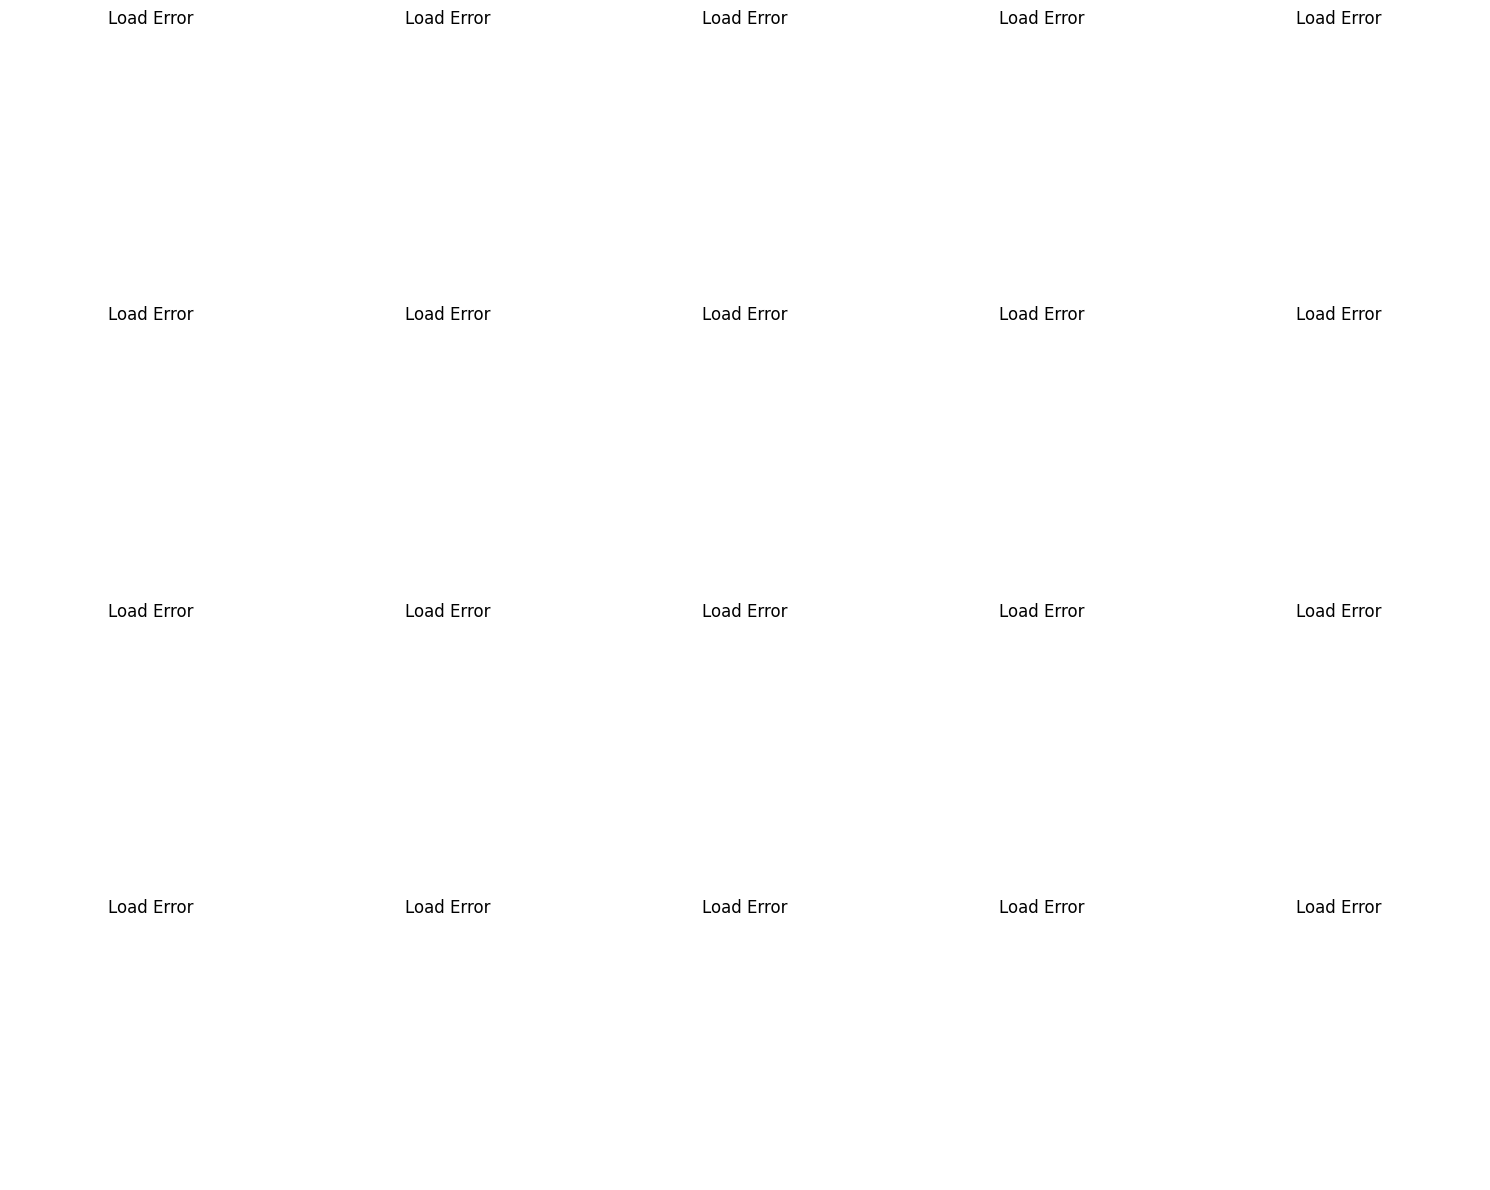


--- COMPARISON: Distilled Student vs Standard ResNet50 ---


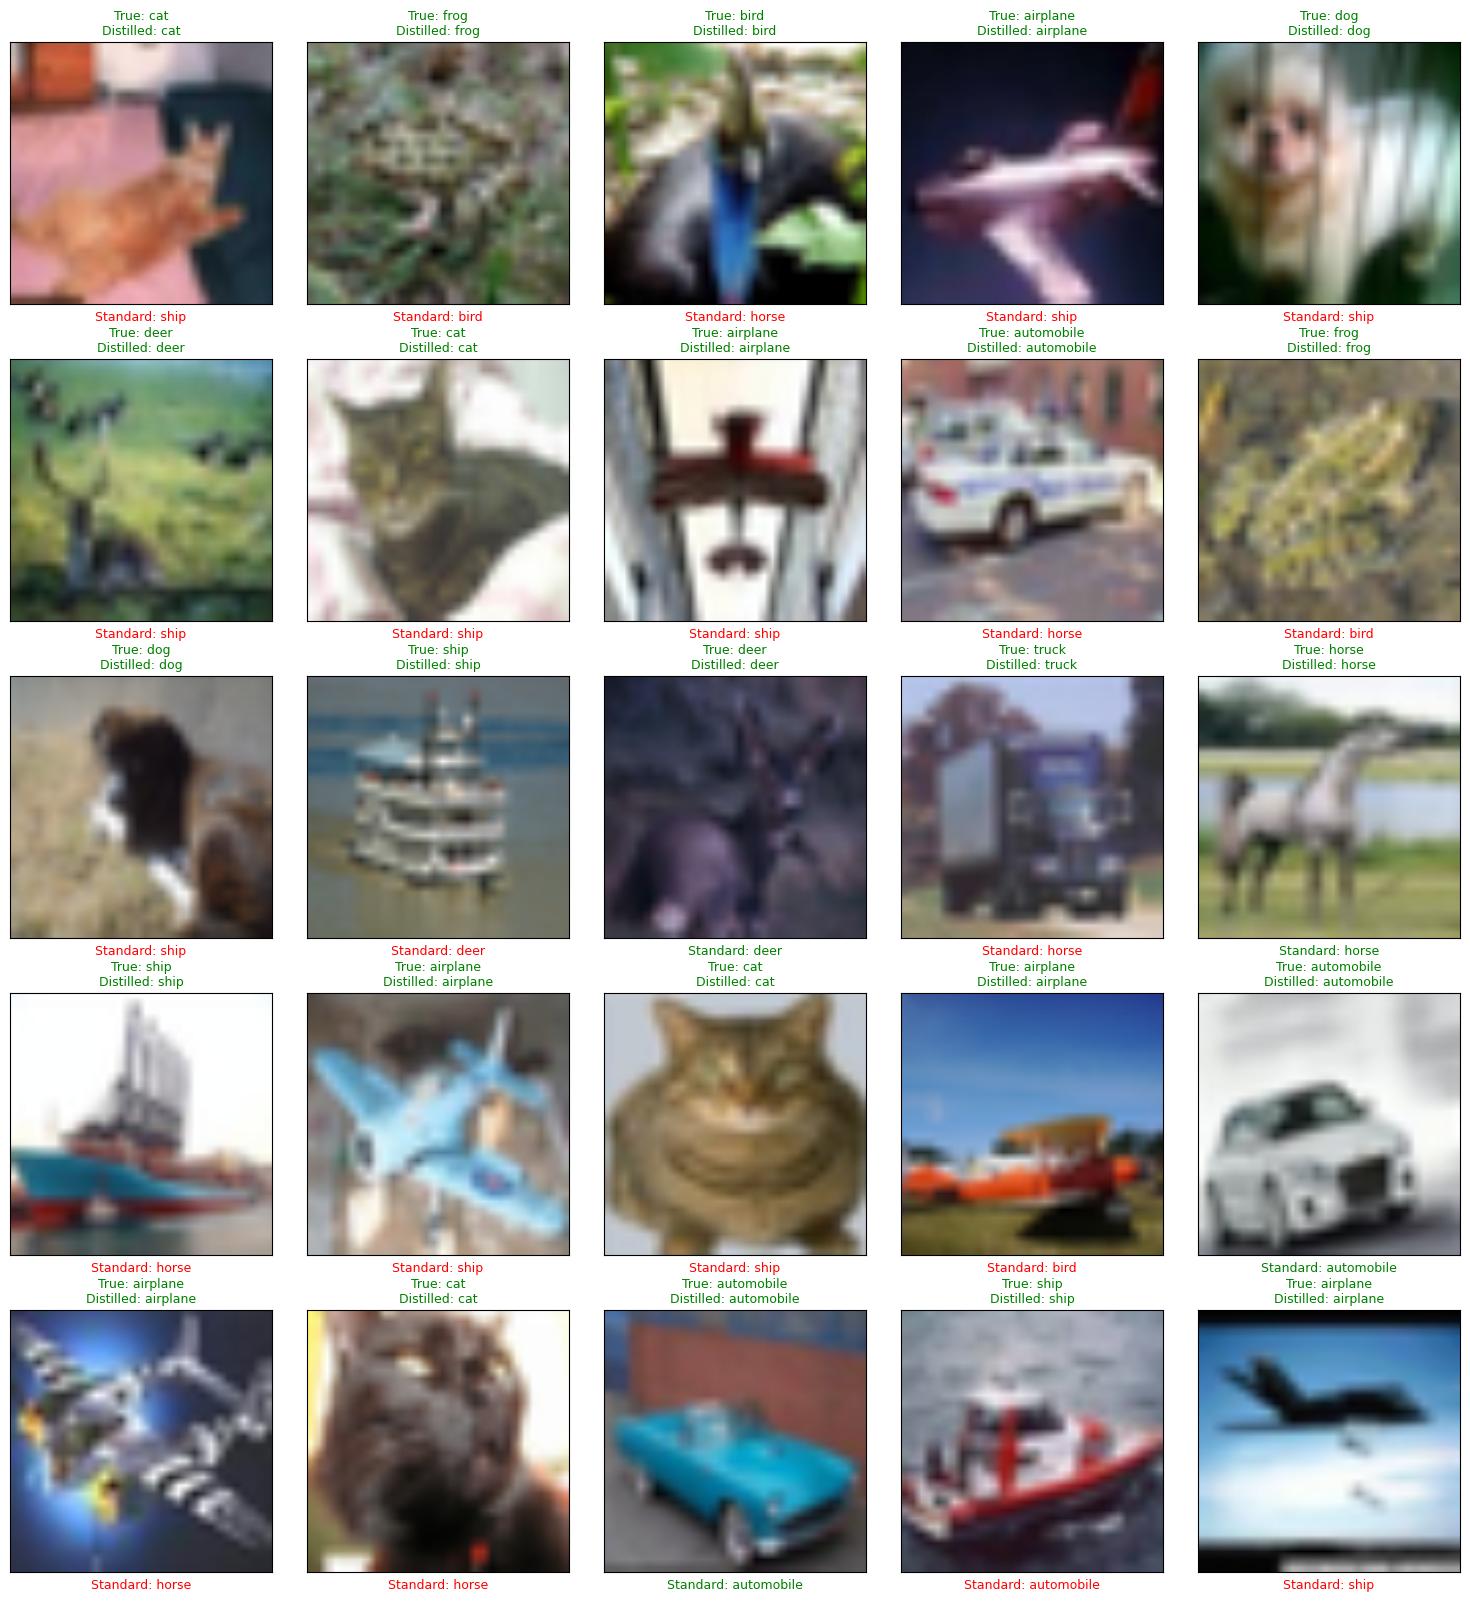


FINAL SCORE on 25 Images:
Distilled Model: 25/25 (100.0%)
Standard Model : 4/25 (16.0%)
Improvement: +84.0%


In [8]:
if __name__ == "__main__":
    history, student_model, test_loader = train_and_validate()
    plot_results(history)
    plot_confusion_matrix_func(student_model, test_loader)
    test_on_20_images(student_model)
    compare_models_25_images(student_model)